# Curve Fitting

Curve fitting estimates the parameters of a mathematical model that best describes a set of experimental or simulated data. Unlike interpolation, which passes exactly through the sampled points, curve fitting determines the model parameters that minimize the discrepancy between the observations and the predicted values. In computational physics, curve fitting is widely used to estimate physical parameters from experimental measurements and numerical simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Radioactive Decay Chain

As an example, consider a two-stage radioactive decay chain,

$$
P \rightarrow D,
$$

where the parent nuclide $P$ decays into the daughter nuclide $D$. Assuming the daughter nuclide also undergoes radioactive decay, the number of daughter nuclei is

$$
N_D(t)=\frac{\lambda_PN_{P,0}}{\lambda_D-\lambda_P}\left(e^{-\lambda_Pt}-e^{-\lambda_Dt}\right),
$$

where $N_{P,0}$ is the initial number of parent nuclei, while $\lambda_P$ and $\lambda_D$ denote the decay constants of the parent and daughter nuclides, respectively.

In [2]:
def decay_daughter(t, NP0, lambda_P, lambda_D):
    return (lambda_P * NP0 / (lambda_D - lambda_P)) * (np.exp(-lambda_P * t) - np.exp(-lambda_D * t))

## Sample Data

Synthetic measurements are generated from the analytical solution with small random perturbations to simulate experimental uncertainty.

In [3]:
NP0, lambda_P, lambda_D = 100, 0.8, 0.5
t_data = np.linspace(0, 10, 51)
y_data = decay_daughter(t_data, NP0, lambda_P, lambda_D) + np.random.normal(0, 0.05, size=t_data.size)

The scatter plot illustrates the noisy daughter-nuclide population before curve fitting is performed.

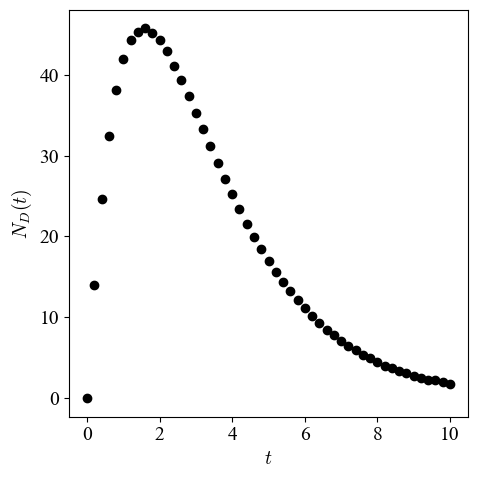

In [4]:
plt.figure(figsize=(5, 5))
plt.scatter(t_data, y_data, color="k")
plt.xlabel(r"$t$")
plt.ylabel(r"$N_D(t)$")
plt.tight_layout()
plt.show()

## Nonlinear Curve Fitting

The objective of curve fitting is to determine the parameter vector

$$
\boldsymbol{\theta}
=
\begin{bmatrix}
N_{P,0}\\
\lambda_P\\
\lambda_D
\end{bmatrix},
$$

by minimizing the sum of squared residuals,

$$
S(\boldsymbol{\theta})=\sum_{i=1}^{n}\left(N_{D,i}-\hat{N}_D(t_i,\boldsymbol{\theta})\right)^2,
$$

where $N_{D,i}$ represents the measured data and $\hat{N}_D$ is the model prediction.

Since the model depends nonlinearly on the unknown parameters, the minimum of $S(\boldsymbol{\theta})$ cannot generally be obtained in closed form. Instead, iterative optimization algorithms are employed to search for the parameter values that minimize the objective function. The following code estimates the optimal parameters using `scipy.optimize.curve_fit`.

In [5]:
popt, pcov = curve_fit(decay_daughter, t_data, y_data, p0=[50, 2, 1])
NP0_fit, lambda_P_fit, lambda_D_fit = popt
y_fit = decay_daughter(t_data, *popt)

In [6]:
popt

array([99.96405507,  0.8002091 ,  0.4998781 ])

The fitted radioactive decay model is compared with the noisy measurements to evaluate how accurately the estimated parameters reproduce the observed data.

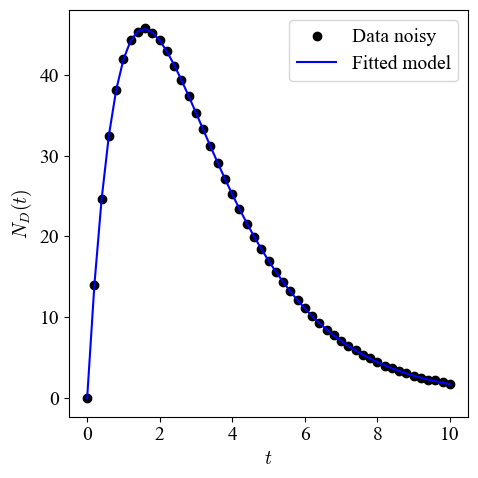

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(t_data, y_data, label="Data noisy", color="k")
plt.plot(t_data, y_fit, label=f"Fitted model", color="b")
plt.xlabel(r"$t$")
plt.ylabel(r"$N_D(t)$")
plt.legend()
plt.tight_layout()
plt.show()

## Model Evaluation

The fitting accuracy is evaluated using the coefficient of determination,

$$
R^2=1-\frac{\sum_{i=1}^{n}(N_{D,i}-\hat{N}_{D,i})^2}{\sum_{i=1}^{n}(N_{D,i}-\bar{N}_D)^2},
$$

the mean absolute error (MAE),

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}\left|N_{D,i}-\hat{N}_{D,i}\right|,
$$

and the root mean squared error (RMSE),

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(N_{D,i}-\hat{N}_{D,i}\right)^2}.
$$

These metrics quantify the agreement between the fitted model and the observed measurements.

In [8]:
r_squared = r2_score(y_data, y_fit)
mae = mean_absolute_error(y_data, y_fit)
rmse = root_mean_squared_error(y_data, y_fit)
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r_squared:.4f}")

MAE: 0.0360, RMSE: 0.0448, R²: 1.0000


## Key Insights

* Curve fitting estimates the parameters of a mathematical model from noisy observations.
* Unlike interpolation, curve fitting does not necessarily pass through every data point.
* Nonlinear models generally require iterative optimization algorithms to estimate the unknown parameters.
* The estimated parameters retain physical meaning, such as the initial parent population and decay constants in radioactive decay.
* Performance metrics such as $R^2$, MAE, and RMSE provide quantitative measures of the agreement between the fitted model and the observed data.